# **Modelo clasificatorio de calidad de manzanas**

In [1]:
# Instalación de librerías básicas
!pip install torch torchvision pandas numpy matplotlib scikit-learn seaborn

In [4]:
import pandas as pd

def load_data_from_github():
    try:
        #URLs Raw de archivos de github
        dataset_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-apple/apple/dataset_manzanas.csv"
        rangos_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-apple/apple/AppleQualTags.csv"

        print("Cargando datos...")

        dataset = pd.read_csv(dataset_url, sep=',')
        rangos = pd.read_csv(rangos_url, sep=';')

        print(f"Dataset cargado: {dataset.shape}")
        print(f"Rangos cargados: {rangos.shape}")

        return dataset, rangos

    except Exception as e:
        print(f"Error: {e}")
        return None, None

## Cargar datos desde GitHub

In [3]:
dataset_df, ranks_df = load_data_from_github()

print("Columnas en dataset_df:", dataset_df.columns.tolist())
print("Columnas en ranks_df:", ranks_df.columns.tolist())

# Si 'Dry matter' no existe, busca el nombre correcto
if 'Dry matter' not in dataset_df.columns:
    print("Busca la columna equivalente a 'Dry matter' en:")
    print(dataset_df.columns.tolist())

Cargando datos...
Dataset cargado: (240, 143)
Rangos cargados: (4, 3)
Columnas en dataset_df: ['Apple', 'Dry matter', '430', '434', '438', '442', '446', '450', '454', '458', '462', '466', '470', '474', '478', '482', '486', '490', '494', '498', '502', '506', '510', '514', '518', '522', '526', '530', '534', '538', '542', '546', '550', '554', '558', '562', '566', '570', '574', '578', '582', '586', '590', '594', '598', '602', '606', '610', '614', '618', '622', '626', '630', '634', '638', '642', '646', '650', '654', '658', '662', '666', '670', '674', '678', '682', '686', '690', '694', '698', '702', '706', '710', '714', '718', '722', '726', '730', '734', '738', '742', '746', '750', '754', '758', '762', '766', '770', '774', '778', '782', '786', '790', '794', '798', '802', '806', '810', '814', '818', '822', '826', '830', '834', '838', '842', '846', '850', '854', '858', '862', '866', '870', '874', '878', '882', '886', '890', '894', '898', '902', '906', '910', '914', '918', '922', '926', '930', 

In [5]:
display(ranks_df)

,Category,Min_DryM,Max_DryM
0,Optima,0.1600,0.2200
1,Estándar,0.1400,0.1600
2,Aceptable,0.1298,0.1400
3,Inaceptable,0.1200,0.1298


## ASIGNAR CATEGORÍA DEL APPLEQUALTAGS.CSV

In [7]:
def define_categories(dry_matter, ranks_df):
    for _, fila in ranks_df.iterrows():
        if fila['Min_DryM'] <= dry_matter <= fila['Max_DryM']:
            return fila['Category']
    return 'Desconocida'

dataset_df['Category'] = dataset_df['Dry matter'].apply(
    lambda x: define_categories(x, ranks_df)
)

##  DISTRIBUCIÓN DE CATEGORIAS

In [8]:
print(dataset_df['Category'].value_counts())

Category
Estándar     156
Optima        76
Aceptable      8
Name: count, dtype: int64


## CODIFICACIÓN TEMPORAL PARA ESTRATIFICAR

In [9]:
category_map = {
    'Optima': 0,
    'Estándar': 1,
    'Aceptable': 2,
    'Inaceptable': 3
}

dataset_df['strat_label'] = dataset_df['Category'].map(category_map)

# X e y GLOBAL
X = dataset_df.drop(columns=['Category','strat_label'])
y = dataset_df['strat_label']

# CHECKPOINT
print(dataset_df[['Category','strat_label']].head())

   Category  strat_label
0    Optima            0
1  Estándar            1
2    Optima            0
3  Estándar            1
4    Optima            0


## Definición de X y Y globales

In [12]:
X = dataset_df.drop(columns=['Category', 'strat_label'])
y = dataset_df['strat_label']

print(dataset_df[['Category', 'strat_label']].head())

   Category  strat_label
0    Optima            0
1  Estándar            1
2    Optima            0
3  Estándar            1
4    Optima            0


# **DEFINICIÓN DE LA ARQUITECTURA DEL MLP**

In [13]:
import torch.nn as nn

class MLP_Apple(nn.Module):

    def __init__(self, input_size, hidden_layers, outputs_size, activation='relu', dropout_rate=0.2):
        super().__init__()

        layers = []
        prev_size = input_size

        # Función de activación
        act_map = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid()
        }
        act = act_map[activation]

        # Hidden layers
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(act)
            layers.append(nn.Dropout(dropout_rate))
            prev_size = h

        layers.append(nn.Linear(prev_size, outputs_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


## STRATIFIED K-FOLD

In [14]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## CHECKPOINT — Validación de folds

In [16]:
from collections import defaultdict

fold_counts = []

for i, (train_idx, val_idx) in enumerate(
        skf.split(dataset_df, dataset_df['strat_label'])):

    print(f"\nFOLD {i+1}")

    train_counts = dataset_df.iloc[train_idx]['Category'].value_counts()
    val_counts   = dataset_df.iloc[val_idx]['Category'].value_counts()

    print("TRAIN", train_counts)
    print("VAL", val_counts)

    for cat in dataset_df['Category'].unique():

        fold_counts.append({
            "fold": i+1,
            "category": cat,
            "train_samples": train_counts.get(cat, 0),
            "val_samples": val_counts.get(cat, 0)
        })



FOLD 1
TRAIN Category
Estándar     125
Optima        60
Aceptable      7
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       16
Aceptable     1
Name: count, dtype: int64

FOLD 2
TRAIN Category
Estándar     124
Optima        61
Aceptable      7
Name: count, dtype: int64
VAL Category
Estándar     32
Optima       15
Aceptable     1
Name: count, dtype: int64

FOLD 3
TRAIN Category
Estándar     125
Optima        61
Aceptable      6
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       15
Aceptable     2
Name: count, dtype: int64

FOLD 4
TRAIN Category
Estándar     125
Optima        61
Aceptable      6
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       15
Aceptable     2
Name: count, dtype: int64

FOLD 5
TRAIN Category
Estándar     125
Optima        61
Aceptable      6
Name: count, dtype: int64
VAL Category
Estándar     31
Optima       15
Aceptable     2
Name: count, dtype: int64


In [20]:
# Verificar cuales son los folds consolidados
fold_df = pd.DataFrame(fold_counts)
print(fold_df.head())

   fold   category  train_samples  val_samples
0     1     Optima             60           16
1     1   Estándar            125           31
2     1  Aceptable              7            1
3     2     Optima             61           15
4     2   Estándar            124           32


In [21]:
# Promediado de los folds por muestra

mean_df = fold_df.groupby("category")[["train_samples", "val_samples"]].mean().reset_index()

mean_df.to_csv("prom_muestras_Apple.csv", index=False)

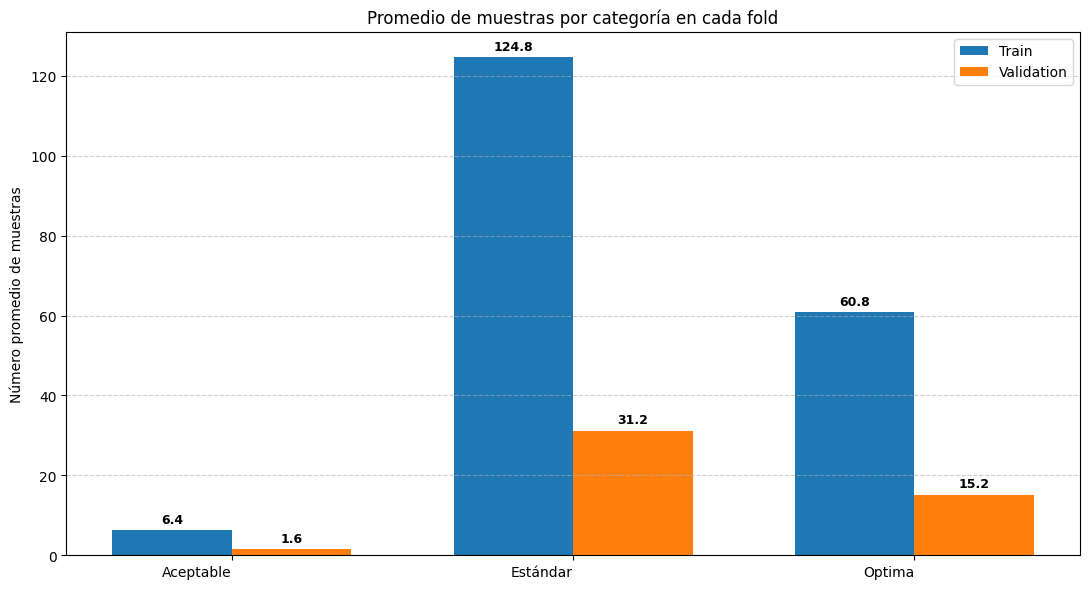

In [22]:
# Graficar estos promedios
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(mean_df))
width = 0.35

plt.figure(figsize=(11,6))

# Barras
bars_train = plt.bar(
    x - width/2,
    mean_df["train_samples"],
    width,
    label="Train"
)

bars_val = plt.bar(
    x + width/2,
    mean_df["val_samples"],
    width,
    label="Validation"
)

# Etiquetas en cada barra
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),                 
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

autolabel(bars_train)
autolabel(bars_val)

# Ejes
plt.xticks(x, mean_df["category"], ha='right')
plt.ylabel("Número promedio de muestras")
plt.title("Promedio de muestras por categoría en cada fold")

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.legend()
plt.tight_layout()
plt.show()

# **ENTRENAMIENTO Y OPTIMIZACIÓN DEL MODELO**

## DICIONARIO DE OPTIMIZADORES

In [23]:
import torch.optim as optim 

OPTIMIZERS = {
    # ADAM
    'adam': lambda params, lr: optim.Adam(params, lr=lr),
    # SGD
    'sgd': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    # RMSprop
    'rmsprop': lambda params, lr: optim.RMSprop(params, lr=lr),
    # AdamW
    'adamW': lambda params, lr: optim.AdamW(params, lr=lr) 
}

## DICCIONARIO DE FUNCIONES DE PERDIDA

In [24]:
CRITERIONS = {
    # Entropia cruzada
    'cross_entropy': nn.CrossEntropyLoss, #Recomendada segun lo que he probado

    'weighted_ce': lambda w=None: nn.CrossEntropyLoss(weight=w),
    '''
    La pérdida de probabilidad logarítmica negativa. Es útil entrenar una clasificación problema con C clases. 
    (NLLLoss - Pytorch2.9 documentation, 2023)
    '''
    'nll': nn.NLLLoss,  
}

# FUNCIÓN DE ENTRENAMIENTO DEL MLP

In [25]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class Trainer:
    def __init__(self, model, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)

        self.history = {
            'train_loss': [],
            'train_accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

    # SETUP --------------------------------------
    def setup(self, 
              optimizer_name='adam', 
              criterion_name='cross_entropy', 
              lr=1e-4, 
              class_weight=None):

        if optimizer_name not in OPTIMIZERS:
            raise ValueError(f"Optimizador no soportado: {optimizer_name}")

        self.optimizer = OPTIMIZERS[optimizer_name](self.model.parameters(), lr)

        # Criterion
        if criterion_name == "weighted_ce":
            self.criterion = CRITERIONS["weighted_ce"](class_weight)
        else:
            self.criterion = CRITERIONS[criterion_name]()
    
    # TRAIN --------------------------------------
    def train_epoch(self, loader):

        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x, y in loader:
            x = x.to(self.device)
            y = y.to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(x)
            loss = self.criterion(logits, y)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total   += y.size(0)

        avg_loss = total_loss / len(loader)
        accuracy = correct / total

        return avg_loss, accuracy 

    # VALIDATION --------------------------------------
    def validate(self, loader):
        self.model.eval()

        total_loss = 0
        all_y = []
        all_pred = []

        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                logits = self.model(x)
                loss = self.criterion(logits, y)

                preds = logits.argmax(dim=1)

                total_loss += loss.item()

                all_y.extend(y.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(all_y, all_pred)
        prec = precision_score(all_y, all_pred, average='macro', zero_division=0)
        rec = recall_score(all_y, all_pred, average='macro', zero_division=0)
        f1 = f1_score(all_y, all_pred, average='macro', zero_division=0)

        return total_loss / len(loader), acc, prec, rec, f1

    #FULL TRAINING LOOP --------------------------------------
    def train(self, train_loader, val_loader, epochs=50):

        for epoch in range(epochs):

            train_loss, train_acc = self.train_epoch(train_loader)

            val_loss, acc, prec, rec, f1 = self.validate(val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['train_accuracy'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_accuracy'].append(acc)
            self.history['val_precision'].append(prec)
            self.history['val_recall'].append(rec)
            self.history['val_f1'].append(f1)

            if epoch % 10 == 0:
                print(
                    f"Epoch {epoch:3d} | "
                    f"Train: {train_loss:.3f} | "
                    f"Val: {val_loss:.3f} | "
                    f"Acc: {acc:.3f} | "
                    f"F1: {f1:.3f}"
                )

        return self.history
    
    # PREDICT FOR EVALUATION --------------------------------------
    def predict(self, loader):

        self.model.eval()

        all_preds = []
        all_true = []

        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                preds = logits.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_true.extend(y.cpu().numpy())

        return all_true, all_preds

In [161]:
import pandas as pd

metrics_all_folds = []

In [ ]:
print("X:", X.shape)
print("y:", y.shape)

train_losses_all = []
val_losses_all   = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    print(f"\n======= FOLD {fold} ======")

    # ======================
    # 1. SPLIT
    # ======================
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]

    Y_train = y.iloc[train_idx]
    Y_val   = y.iloc[val_idx]

    # ======================
    # 2. LIMPIEZA DE BANDAS
    # ======================
    spectral_bands = [c for c in X_train.columns if c not in ['Apple']]

    X_train_clean = X_train[spectral_bands]
    X_val_clean   = X_val[spectral_bands]

    #DEFINIR INPUT SIZE DE LA RED
    num_features = X_train_clean.shape[1]

    # 3.NORMALIZACIÓN (AQUÍ VA)
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_clean)  # SOLO train
    X_val_scaled   = scaler.transform(X_val_clean)        # aplicar a val

    # ======================
    # 3. OVERSAMPLING 
    # ======================
    from imblearn.over_sampling import RandomOverSampler, SMOTE

    ros = RandomOverSampler(random_state=42)
    # ros = SMOTE(random_state=42)

    X_train_ros, Y_train_ros = ros.fit_resample(
        X_train_clean.values,
        Y_train
    )

    # ======================
    # 4. TENSORES
    # ======================
    X_train_tensor = torch.FloatTensor(X_train_ros)
    X_val_tensor   = torch.FloatTensor(X_val_clean.values)

    # Y_train_ros and Y_val already contain numerical labels (0, 1, 2) from category_map.
    # No need to apply label_encoder.transform() as it expects string labels.
    Y_train_tensor = torch.LongTensor(Y_train_ros.values)
    Y_val_tensor   = torch.LongTensor(Y_val.values)

    # ======================
    # 5. DATASET Y LOADER
    # ======================
    train_dataset = TensorDataset(X_train_tensor,Y_train_tensor)
    val_dataset   = TensorDataset(X_val_tensor,  Y_val_tensor)

    train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader    = DataLoader(val_dataset,   batch_size=64, shuffle=False)

    # ======================
    # 6. MODELO + TRAIN
    # ======================
    model = MLP_Apple(
        input_size=num_features,
        hidden_layers=[128, 64],
        outputs_size=3,
        activation='relu',
        dropout_rate=0.35
    )

    trainer = Trainer(model)
    trainer.setup(lr=0.001)

    history = trainer.train(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=150
    )

    # ======================
    # 7. GUARDAR RESULTADOS
    # ======================

    # guardas métricas de este fold
    train_losses_all.append(history['train_loss'][-1])
    val_losses_all.append(history['val_loss'][-1])

    # The history returned by trainer.train already contains all epoch-wise metrics.
    # No need to reassign 'history = trainer.history' here.

    for epoch in range(len(history['train_loss'])):
        metrics_all_folds.append({
            'fold': fold + 1,
            'epoch': epoch,
            'train_loss': history['train_loss'][epoch],
            'train_accuracy': history['train_accuracy'][epoch], # Added train_accuracy
            'val_loss': history['val_loss'][epoch],
            'val_accuracy': history['val_accuracy'][epoch],
            'val_precision': history['val_precision'][epoch],
            'val_recall': history['val_recall'][epoch],
            'val_f1': history['val_f1'][epoch]
        })


X: (240, 143)
y: (240,)

======= FOLD 1 ======
Epoch   0 | Train: 1.109 | Val: 1.143 | Acc: 0.167 | F1: 0.119
Epoch  10 | Train: 1.094 | Val: 1.099 | Acc: 0.375 | F1: 0.308
Epoch  20 | Train: 1.089 | Val: 1.062 | Acc: 0.417 | F1: 0.205
Epoch  30 | Train: 1.067 | Val: 1.080 | Acc: 0.396 | F1: 0.269
Epoch  40 | Train: 1.052 | Val: 1.092 | Acc: 0.396 | F1: 0.310
Epoch  50 | Train: 1.065 | Val: 1.130 | Acc: 0.333 | F1: 0.250
Epoch  60 | Train: 1.057 | Val: 1.087 | Acc: 0.438 | F1: 0.349
Epoch  70 | Train: 1.057 | Val: 1.069 | Acc: 0.396 | F1: 0.269
Epoch  80 | Train: 1.033 | Val: 1.084 | Acc: 0.375 | F1: 0.264
Epoch  90 | Train: 1.033 | Val: 1.058 | Acc: 0.417 | F1: 0.299
Epoch 100 | Train: 1.024 | Val: 1.038 | Acc: 0.417 | F1: 0.302
Epoch 110 | Train: 1.008 | Val: 1.015 | Acc: 0.500 | F1: 0.229
Epoch 120 | Train: 0.995 | Val: 1.060 | Acc: 0.333 | F1: 0.287
Epoch 130 | Train: 1.000 | Val: 1.045 | Acc: 0.333 | F1: 0.299
Epoch 140 | Train: 0.992 | Val: 1.034 | Acc: 0.396 | F1: 0.328

=======

In [163]:
df_metrics = pd.DataFrame(metrics_all_folds)

df_metrics.to_csv("metricas_kfold_modelo.csv", index=False)

print("CSV generado:", df_metrics.head())


CSV generado:    fold  epoch  train_loss  train_accuracy  val_loss  val_accuracy  \
0     2      0    1.108518        0.322667  1.143326      0.166667   
1     2      1    1.097976        0.360000  1.115004      0.020833   
2     2      2    1.101187        0.341333  1.102821      0.125000   
3     2      3    1.102859        0.341333  1.084909      0.645833   
4     2      4    1.100864        0.293333  1.075841      0.645833   

   val_precision  val_recall    val_f1  
0       0.091954    0.166667  0.118519  
1       0.006944    0.333333  0.013605  
2       0.193732    0.387097  0.100000  
3       0.215278    0.333333  0.261603  
4       0.215278    0.333333  0.261603  


In [164]:
#@title GRÁFICO PROMEDIO POR FOLD
import numpy as np

tags = ['Optima', 'Estándar', 'Aceptable']

stats_folds = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(dataset_df, dataset_df['strat_label']), 1):

    train_counts = dataset_df.iloc[train_idx]['Category'].value_counts()
    val_counts   = dataset_df.iloc[val_idx]['Category'].value_counts()

    stats_folds.append({
        "train": [train_counts.get(cat, 0) for cat in tags],
        "val":   [val_counts.get(cat, 0) for cat in tags],
    })


In [165]:
mean_train = np.mean([f['train'] for f in stats_folds], axis=0)
mean_val   = np.mean([f['val'] for f in stats_folds], axis=0)


In [166]:
print("Train promedio:", mean_train)
print("Val promedio:", mean_val)


Train promedio: [ 60.8 124.8   6.4]
Val promedio: [15.2 31.2  1.6]


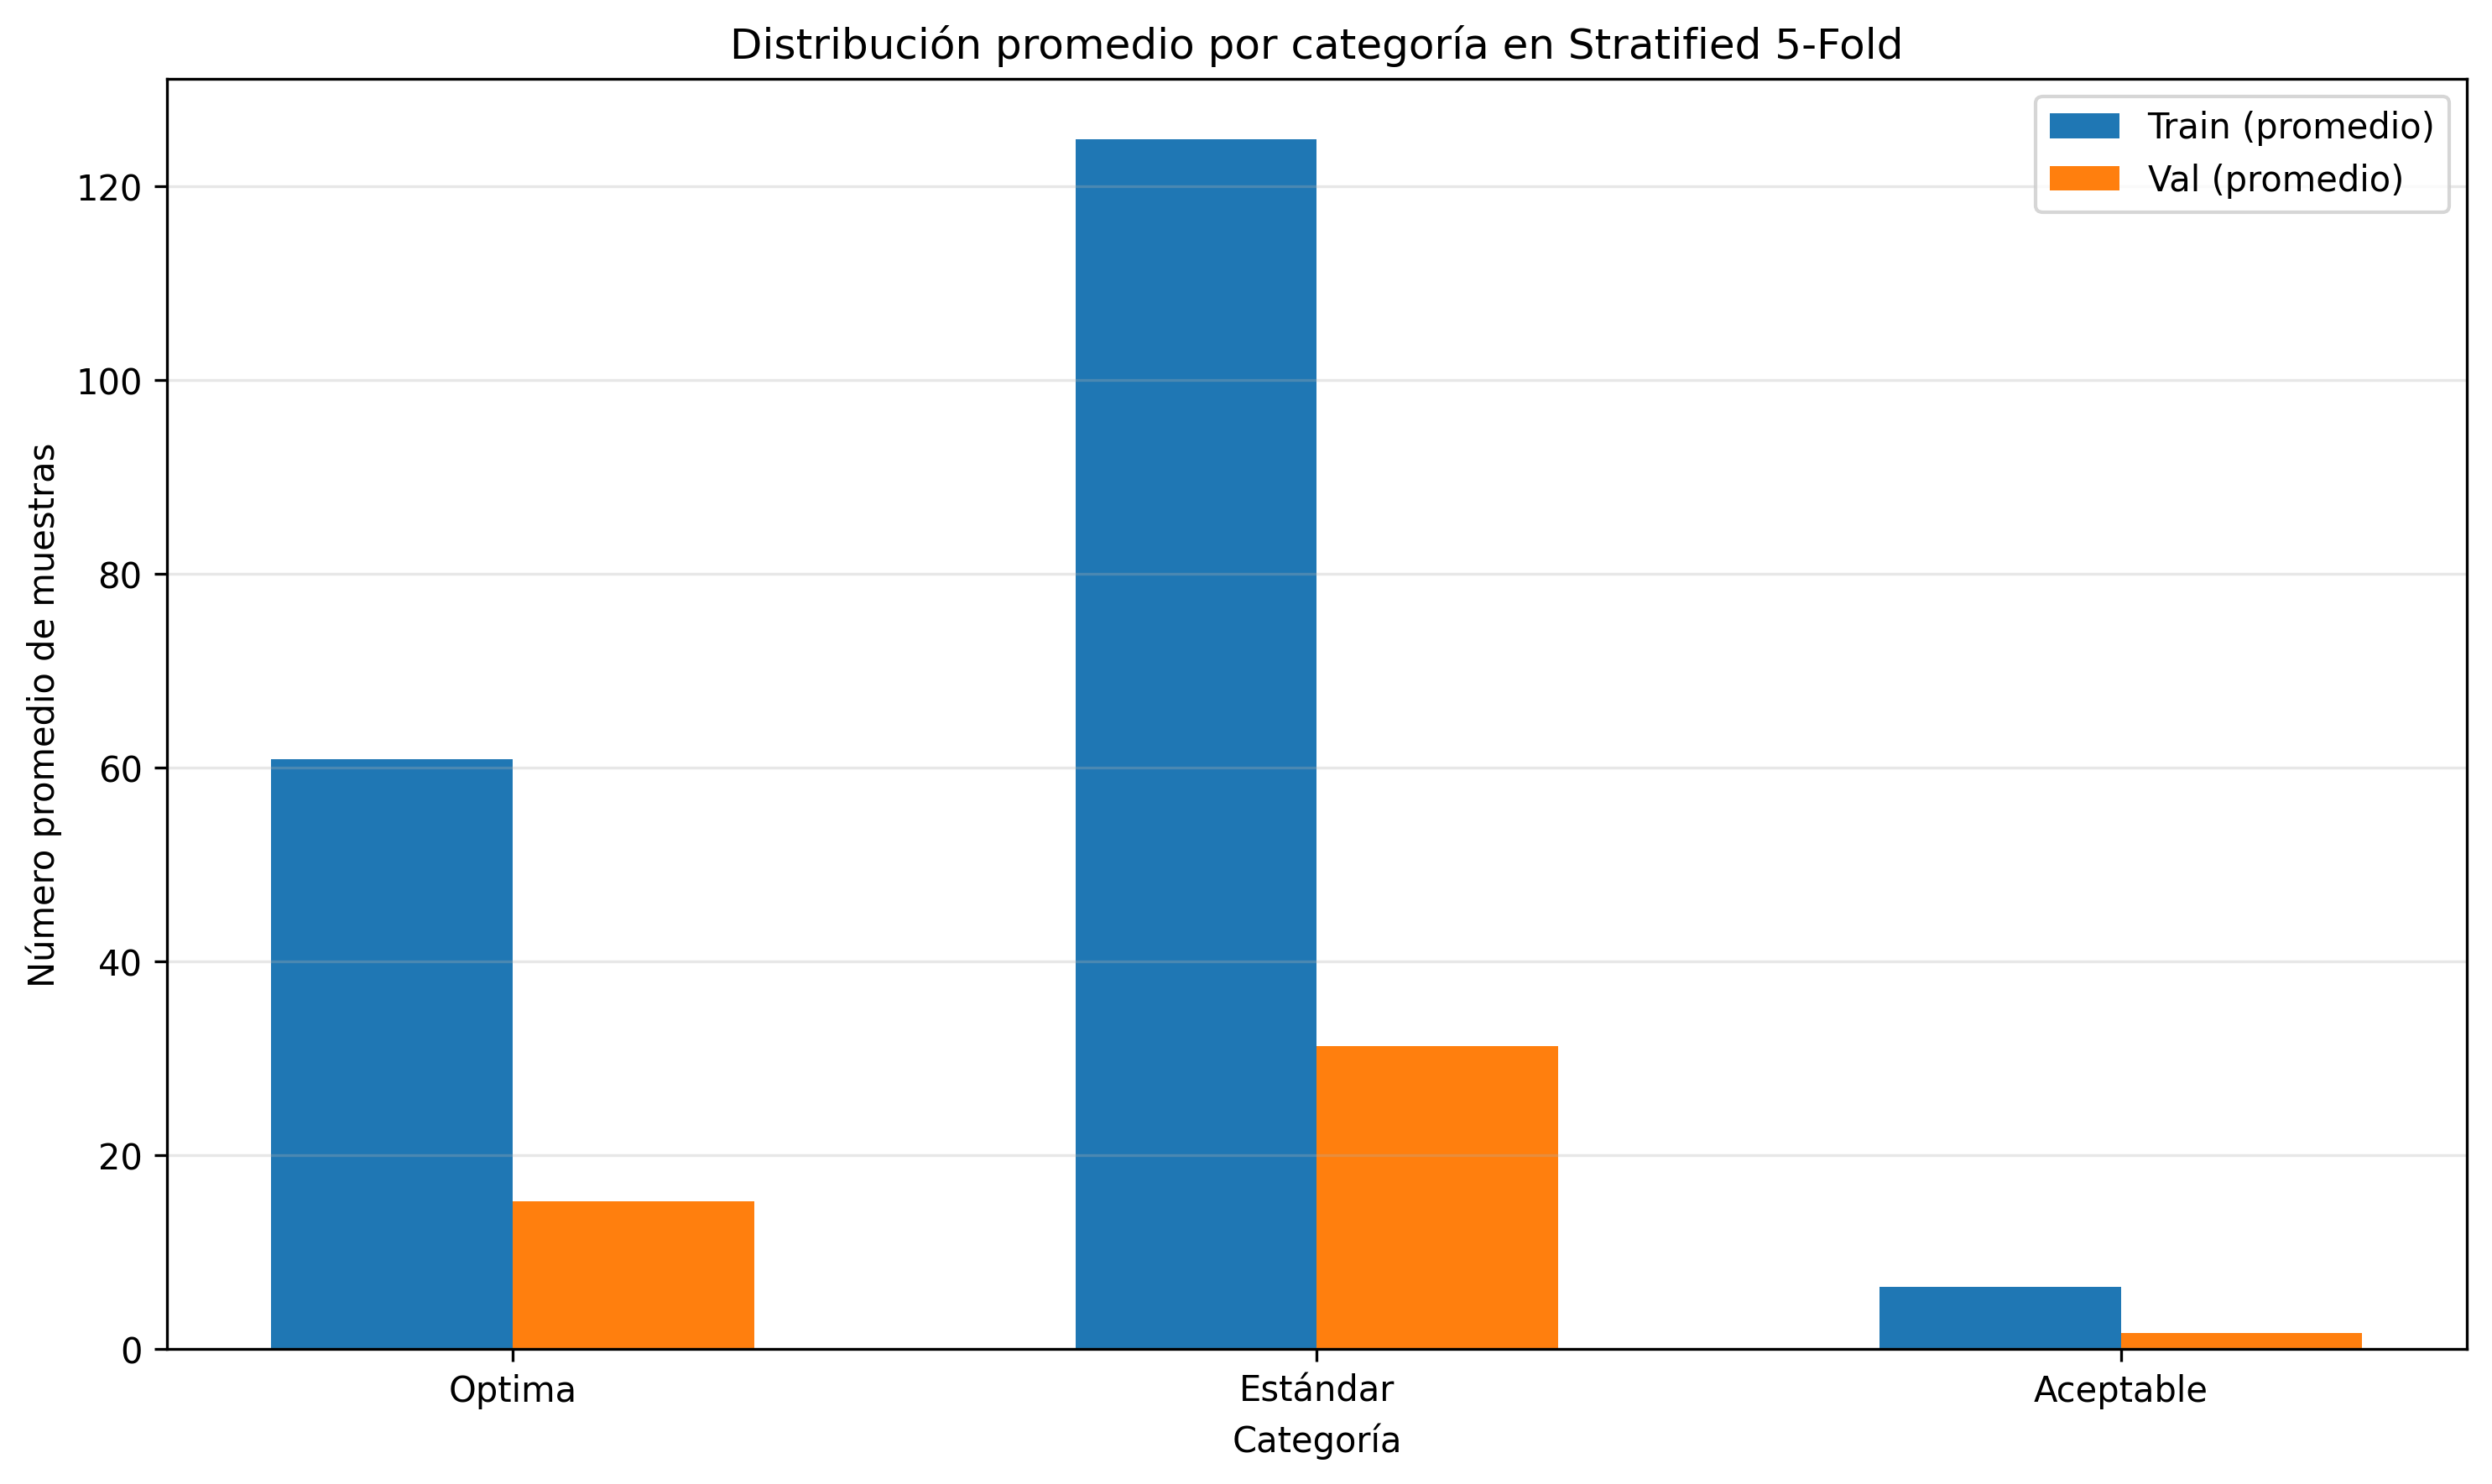

In [167]:
bars_train = mean_train
bars_val   = mean_val

barW = 0.30
r = np.arange(len(tags))
r2 = r + barW

fig, ax = plt.subplots(figsize=(10,6), dpi=300)

ax.bar(r, bars_train, width=barW, label="Train (promedio)")
ax.bar(r2, bars_val, width=barW, label="Val (promedio)")

ax.set_xticks(r + barW/2)
ax.set_xticklabels(tags)

ax.set_ylabel("Número promedio de muestras")
ax.set_xlabel("Categoría")

ax.set_title("Distribución promedio por categoría en Stratified 5-Fold")

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

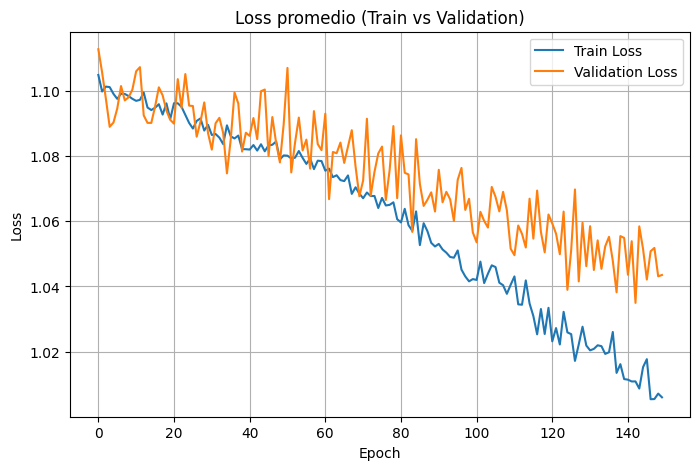

In [168]:
#@title GRÁFICOS: TRAIN LOSS vs VAL LOSS
import matplotlib.pyplot as plt

# Promedio por epoch
mean_df = df_metrics.groupby('epoch').mean()

plt.figure(figsize=(8,5))
plt.plot(mean_df.index, mean_df['train_loss'], label='Train Loss')
plt.plot(mean_df.index, mean_df['val_loss'], label='Validation Loss')

plt.title('Loss promedio (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


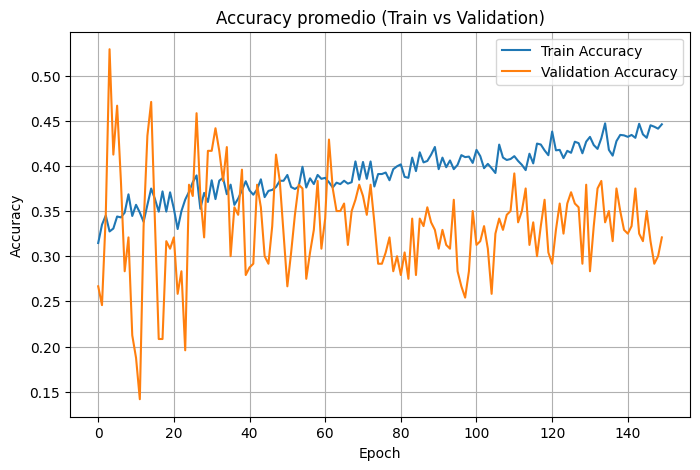

In [169]:
#@title GRÁFICO: TRAIN ACCURACY vs VAL ACCURACY
mean_df = df_metrics.groupby('epoch').mean()

plt.figure(figsize=(8,5))
plt.plot(mean_df.index, mean_df['train_accuracy'], label='Train Accuracy')
plt.plot(mean_df.index, mean_df['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy promedio (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


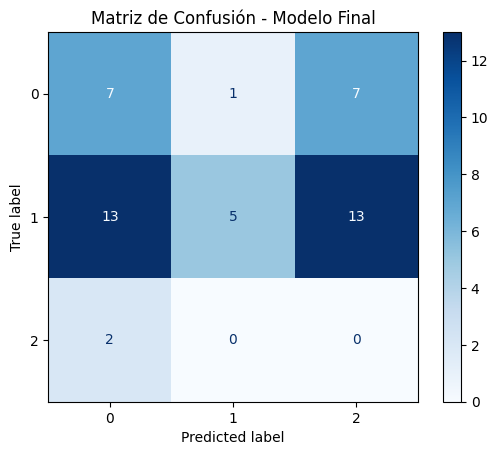

In [170]:
#@title MATRIZ DE CONFUSIÓN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_true = []
all_pred = []

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(trainer.device)
        y = y.to(trainer.device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        all_true.extend(y.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true, all_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - Modelo Final")
plt.show()
